#Importation des données dans Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Importation des bibliothèques et les métriques à utiliser

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
df = pd.read_csv('drive/MyDrive/PJME_hourly.csv')

#Manipulation des données

In [ ]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [ ]:
df.isna().sum()

,0
Datetime,0
PJME_MW,0


In [ ]:
df=df.set_index('Datetime') #Indexation de la colonne Datetime
df.index=pd.to_datetime(df.index) #Conversion du type d'un objet vers datetime

#Visualisation des données

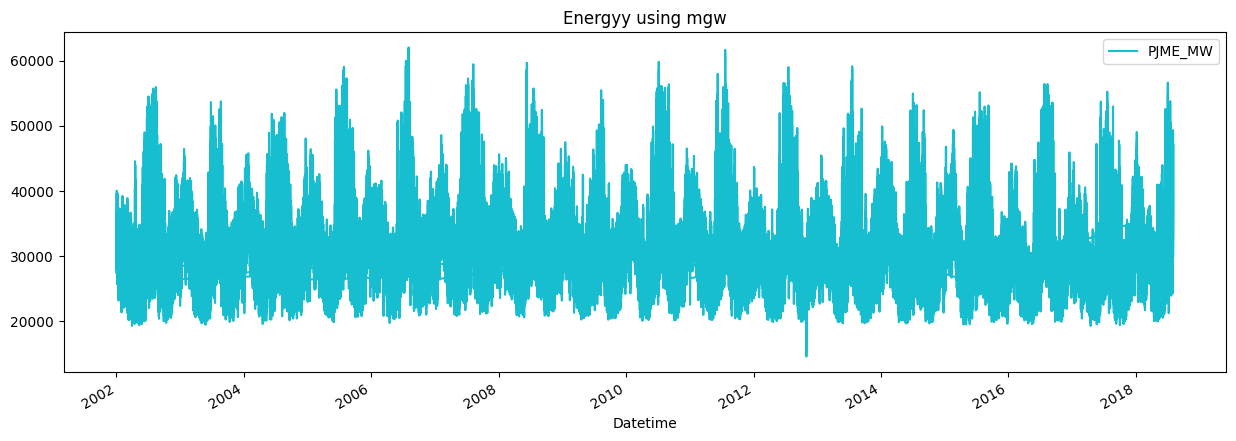

In [ ]:
color_pal = sns.color_palette()
df.plot(figsize=(15,5),style= '-',color=color_pal[9], title='Energyy using mgw')
plt.show()

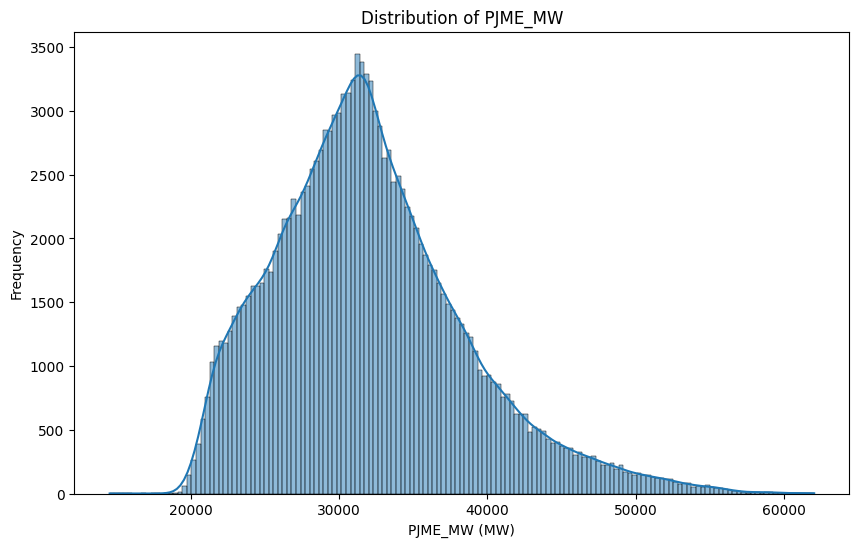

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PJME_MW'], kde=True, color=color_pal[0])
plt.title('Distribution of PJME_MW')
plt.xlabel('PJME_MW (MW)')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='Datetime'>

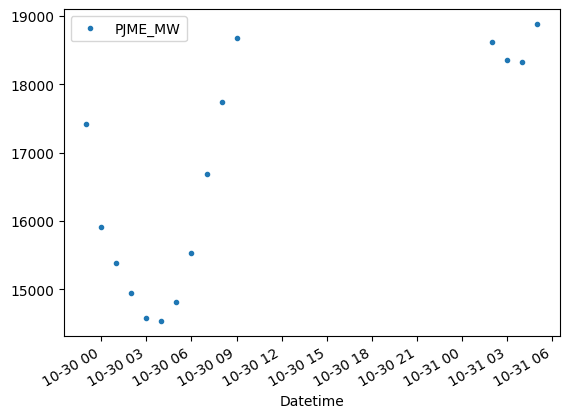

In [ ]:
df.query('PJME_MW < 19000').plot(style='.')

#Identification des outliers

In [ ]:
lower_bound = 19000
# Identify outliers
outliers = df[(df['PJME_MW'] < lower_bound) ]
print(f"Number of outliers identified: {len(outliers)}")
print("Outliers:")
display(outliers)
# Remove outliers
df_cleaned = df[(df['PJME_MW'] >= lower_bound)].copy()
print(f"\nNumber of rows after removing outliers: {len(df_cleaned)}")

Number of outliers identified: 15
Outliers:


,PJME_MW
Datetime,
2012-10-31 02:00:00,18618.0
2012-10-31 03:00:00,18350.0
2012-10-31 04:00:00,18330.0
2012-10-31 05:00:00,18880.0
2012-10-30 01:00:00,15390.0
2012-10-30 02:00:00,14955.0
2012-10-30 03:00:00,14586.0
2012-10-30 04:00:00,14544.0
2012-10-30 05:00:00,14821.0



Number of rows after removing outliers: 145351


#Machine Learning

In [ ]:
#Séparer la dataframe en train set (avant 2015) et test set (après 2015)
train_set=df_cleaned.loc[df_cleaned.index< '2015-01-01']
test_set=df_cleaned.loc[df_cleaned.index>='2015-01-01']

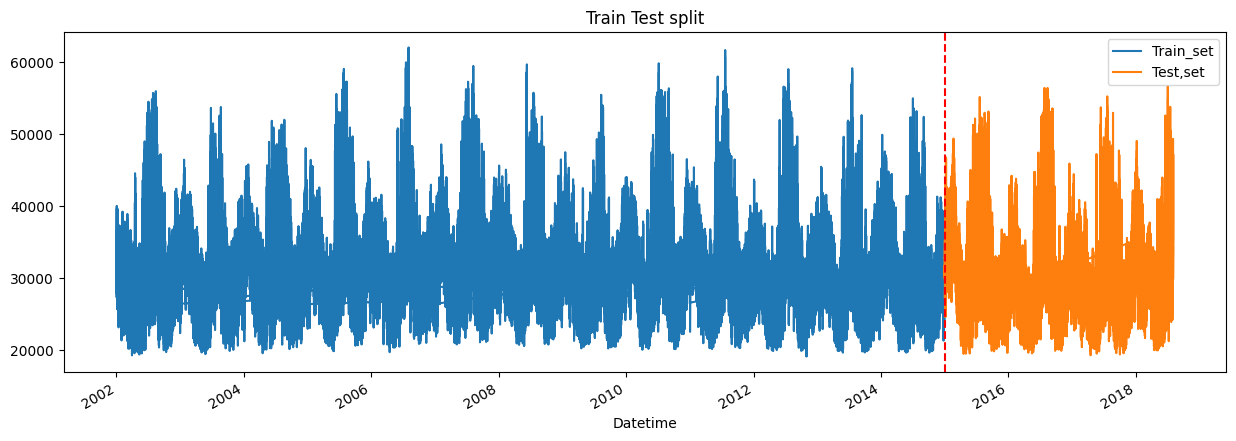

In [ ]:
#Visualiser la partie train_set et test_set
fig,ax=plt.subplots(figsize=(15,5))
train_set.plot(ax=ax)
test_set.plot(ax=ax)
ax.axvline('2015-01-01',color='red', ls='--')
plt.legend(['Train_set','Test,set'])
plt.title('Train Test split')
plt.show()

In [ ]:
#Extraire des variables temporelles : heure, jour de la semaine, mois, année, etc.
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df
df_cleaned = create_features(df_cleaned)

In [ ]:
#Créer des variables de retard (lag) : valeurs de PJME_MW à J-364, J-728, J-1092.
def add_lags(df):
    target_map = df['PJME_MW'].to_dict()
    df['lag1year'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag2year'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3year'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df
df_cleaned= add_lags(df_cleaned)

In [ ]:
# Séparer en caractéristiques (X) et la cible (y)
X = df_cleaned.drop('PJME_MW', axis=1)
y = df_cleaned['PJME_MW']

# Diviser les données en données d'entraînement et de test en se basant à la date
x_train_xgb = X.loc[X.index < '2015-01-01']
y_train_xgb = y.loc[y.index < '2015-01-01']

x_test_xgb = X.loc[X.index >= '2015-01-01']
y_test_xgb = y.loc[y.index >= '2015-01-01']

print("Shape of x_train_xgb:", x_train_xgb.shape)
print("Shape of y_train_xgb:", y_train_xgb.shape)
print("Shape of x_test_xgb:", x_test_xgb.shape)
print("Shape of y_test_xgb:", y_test_xgb.shape)

Shape of x_train_xgb: (113911, 11)
Shape of y_train_xgb: (113911,)
Shape of x_test_xgb: (31440, 11)
Shape of y_test_xgb: (31440,)


In [ ]:
x_train_xgb

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1year,lag2year,lag3year
Datetime,,,,,,,,,,,
2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,30393.0,NaN,NaN
2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,29265.0,NaN,NaN
2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,28357.0,NaN,NaN
2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,27899.0,NaN,NaN
2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,28057.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2014-01-01 20:00:00,20,2,1,1,2014,1,1,1,40800.0,42517.0,40132.0
2014-01-01 21:00:00,21,2,1,1,2014,1,1,1,39963.0,41422.0,39466.0
2014-01-01 22:00:00,22,2,1,1,2014,1,1,1,38193.0,39367.0,37817.0


In [ ]:
#Séparer en 5 folds pour les utiliser dans la validation croisée
N_SPLITS  = 5
TEST_SIZE = 24*365

tss =TimeSeriesSplit(n_splits=N_SPLITS , test_size=TEST_SIZE ,gap= 24)

df_cleaned = df_cleaned.sort_index()

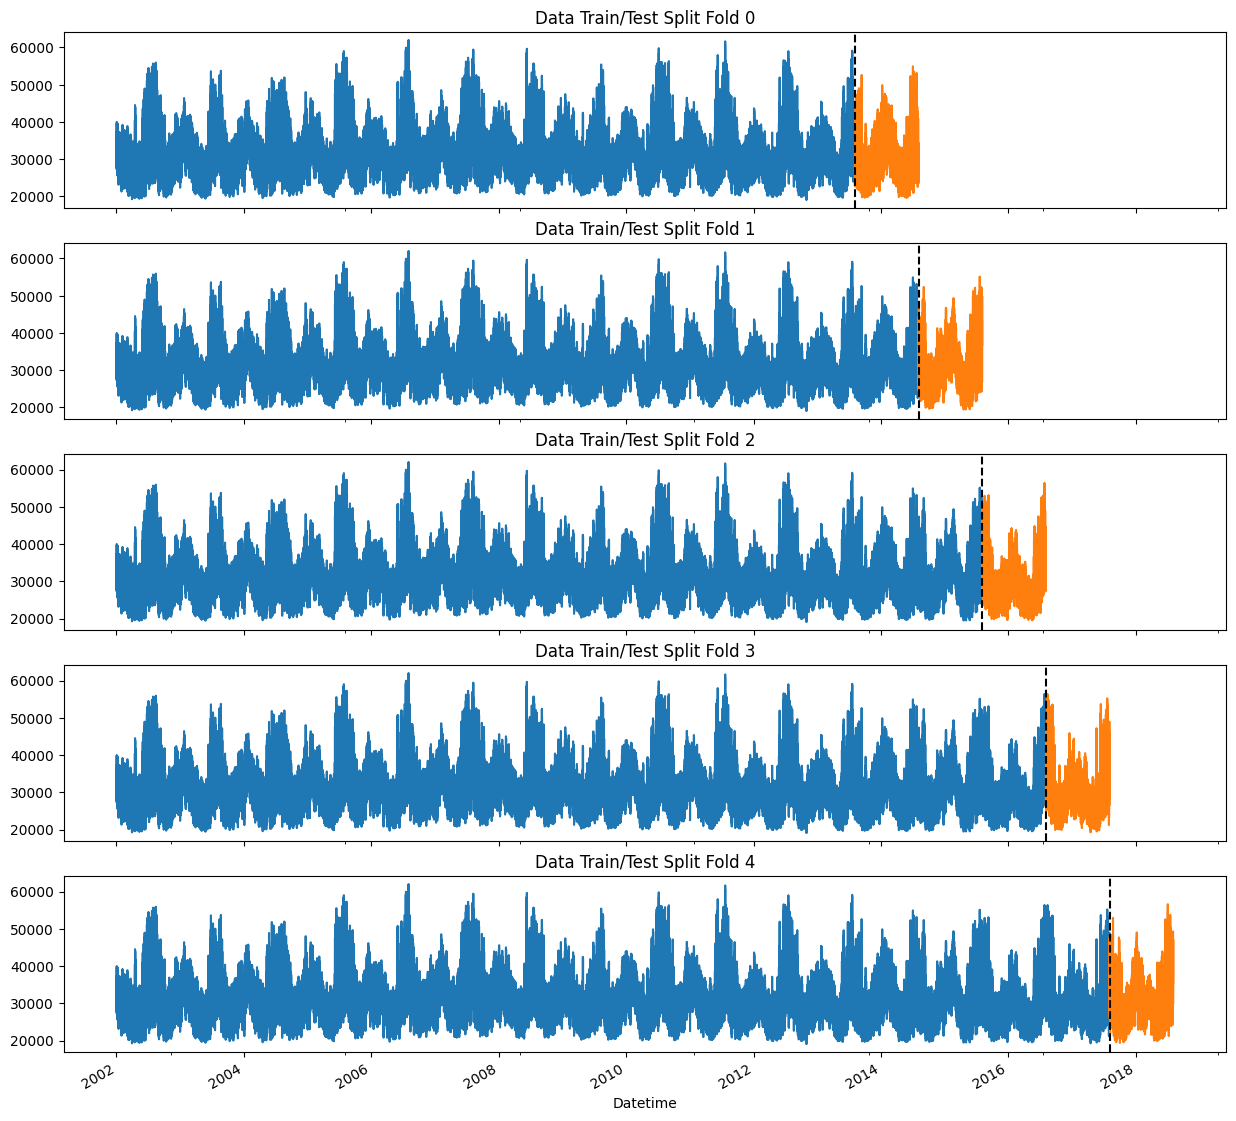

In [ ]:
#Visualiser les folds
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df_cleaned):
    train = df_cleaned.iloc[train_idx]
    test = df_cleaned.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

In [ ]:
#Entraîner les folds avec le modèle de xgboost et en utilisant le grille de recherche
from sklearn.model_selection import GridSearchCV

fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df_cleaned):
    train = df_cleaned.iloc[train_idx]
    test = df_cleaned.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
                'lag1year','lag2year','lag3year']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    # Définir les paramètres pour GridSearchCV
    param_grid = {
        'n_estimators': [500, 1000, 1500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
    }

    # Initialiser le XGBoost Regressor
    xgb_model = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                                 objective='reg:squarederror', # Changed from reg:linear
                                 early_stopping_rounds=50)

    # Initialiser GridSearchCV
    grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                               scoring='neg_root_mean_squared_error', cv=3, verbose=2)

    grid_search.fit(X_train, y_train,
                    eval_set=[(X_train, y_train), (X_test, y_test)],
                    verbose=False) # Set verbose to False for cleaner output

    # Avoir le meilleur modèle pour GridSearchCV
    reg = grid_search.best_estimator_

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)
    fold += 1

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=500; total time=  13.8s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=500; total time=  15.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=500; total time=  13.8s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1000; total time=  15.2s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1000; total time=  15.8s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1000; total time=  27.6s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1500; total time=  14.0s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1500; total time=  13.7s
[CV] END .learning_rate=0.01, max_depth=3, n_estimators=1500; total time=  33.7s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=500; total time=  17.7s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=500; total time=  15.3s
[CV] END ..learning_rate=0.01, max_depth=5, n_es

In [ ]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3693.2392
Fold scores:[np.float64(3760.8277187583353), np.float64(3377.985055083448), np.float64(3469.2722118748306), np.float64(3933.471105136856), np.float64(3924.6397122786425)]


In [ ]:
# Refaire l'entraînement pour toutes les données
df_cleaned = create_features(df_cleaned)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag1year','lag2year','lag3year']
TARGET = 'PJME_MW'

X_all = df_cleaned[FEATURES]
y_all = df_cleaned[TARGET]

# Utiliser les meilleures paramètres trouvés durant la validation croisée
reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       n_estimators=grid_search.best_params_['n_estimators'],
                       objective='reg:squarederror',
                       max_depth=grid_search.best_params_['max_depth'],
                       learning_rate=grid_search.best_params_['learning_rate'])

reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)

reg.score(X_all,y_all)

[0]	validation_0-rmse:29501.61000
[100]	validation_0-rmse:2824.07129
[200]	validation_0-rmse:2564.71852
[300]	validation_0-rmse:2400.52799
[400]	validation_0-rmse:2280.60784
[499]	validation_0-rmse:2179.62209


0.8862443544698763

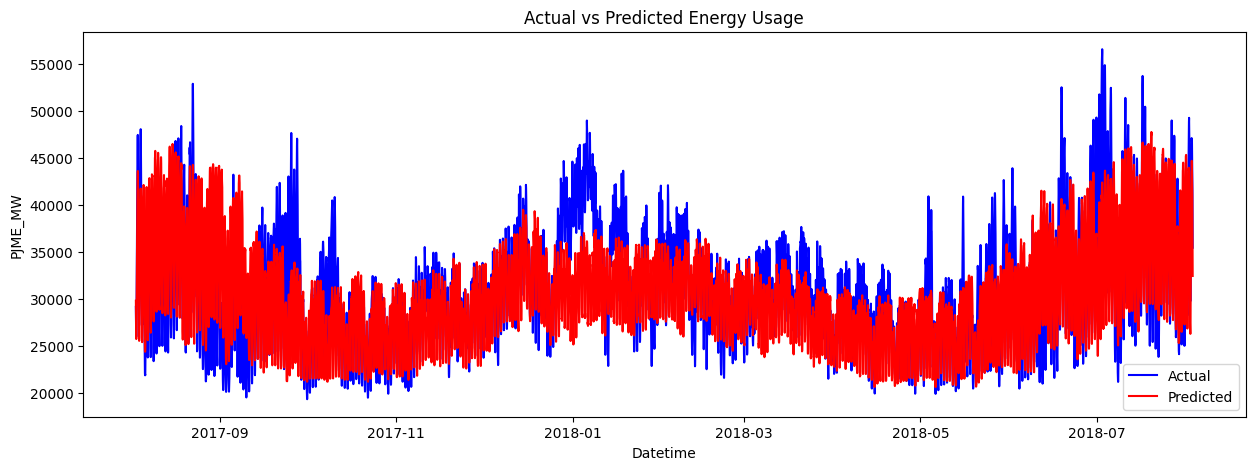

In [ ]:
#Visualiser les données qu'on a prédit et les données réelles
plt.figure(figsize=(15, 5))
last_fold_test_idx = list(tss.split(df_cleaned))[-1][1]
y_test_last_fold = df_cleaned.iloc[last_fold_test_idx]['PJME_MW']

plt.plot(y_test_last_fold.index, y_test_last_fold, label='Actual', color='blue')
plt.plot(y_test_last_fold.index, preds[-1], label='Predicted', color='red')
plt.title('Actual vs Predicted Energy Usage')
plt.xlabel('Datetime')
plt.ylabel('PJME_MW')
plt.legend()
plt.show()

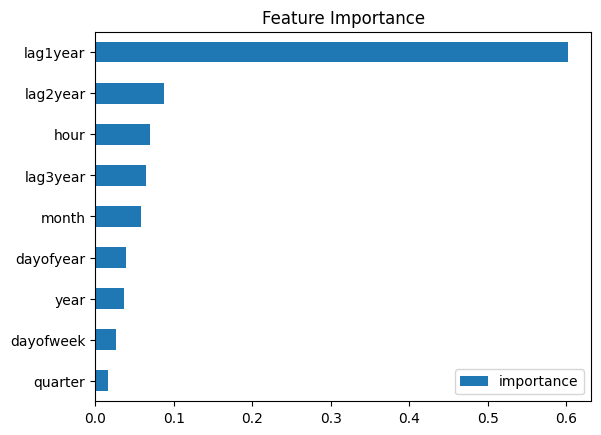

In [ ]:
#Visualiser l'importance des caractèristiques
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

#Prédiction du futur (de 2018 à 2021)

In [ ]:
#Créer une plage de dates futures.
future = pd.date_range(start='2018-08-03',end='2021-08-01',freq='1h')
future_df = pd.DataFrame(index=future)

In [ ]:
future_df['isFuture']= True
df['isFuture']= False
df_and_future = pd.concat([df,future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [ ]:
future_w_features = df_and_future.query('isFuture').copy()
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

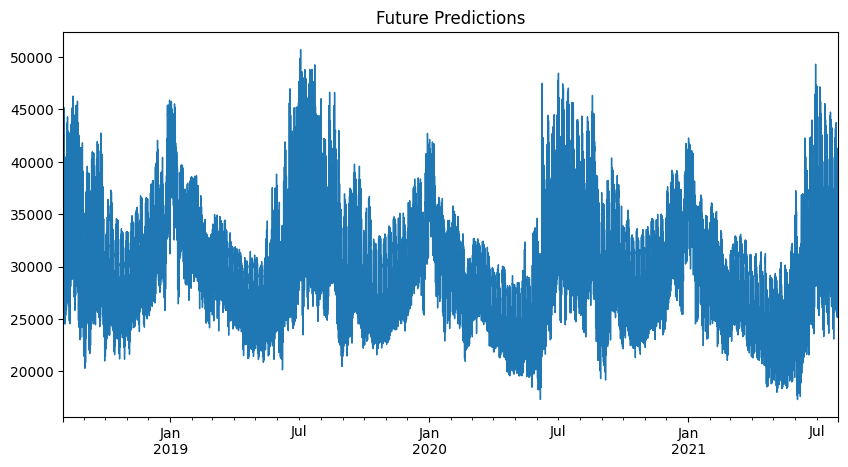

In [ ]:
future_w_features['pred'].plot(figsize=(10, 5),
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

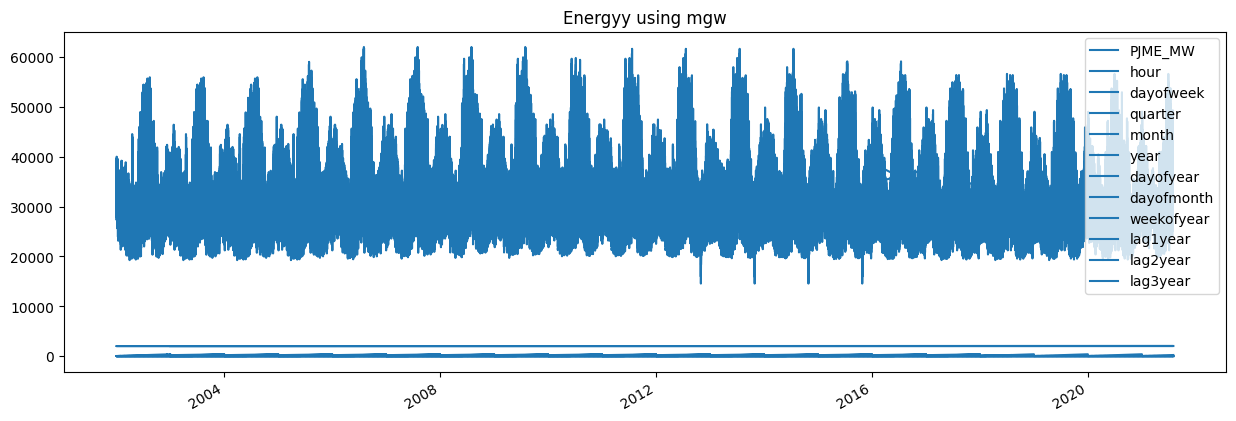

In [ ]:
#Visualiser toutes les données (passé et futur)
color_pal = sns.color_palette()
df_and_future.plot(figsize=(15,5),style= '-',color=color_pal[0], title='Energyy using mgw')
plt.show()